<a href="https://colab.research.google.com/github/hafizurrahman1014-sys/Machine-Learning-projects/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import os
import numpy as np
import pandas as pd

# Assuming the dataset is available at this path (e.g., your uploaded file)
csv_file = '/content/bank-full.csv'

### Load Dataset
This cell loads the bank marketing dataset from the specified CSV file into a pandas DataFrame. We're assuming the file is located at `/content/bank-full.csv` and uses a semicolon (`;`) as a separator.

In [37]:
# Load dataset
df = pd.read_csv(csv_file, sep=';')

# Display the first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Inspect Dataset Structure
This cell uses `df.info()` to print a concise summary of the DataFrame, including the number of entries, column names, non-null counts, and data types. This helps in understanding the dataset's overall structure and identifying any missing values.

In [11]:
# Check dataset structure, column names, memory usage, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


### Check Data Types
This cell displays the data type of each column in the DataFrame, which is crucial for data preprocessing and ensuring data consistency.

In [12]:
# Inspect data types of each column
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


### Explore Unique Values of Categorical Columns
This cell prints the unique values for various categorical columns in the dataset. This step is essential for understanding the different categories present and for planning encoding strategies later on.

In [13]:
print(df['job'].unique())
print(df['marital'].unique())
print(df['education'].unique())
print(df['default'].unique())
print(df['housing'].unique())
print(df['loan'].unique())
print(df['contact'].unique())
print(df['month'].unique())
print(df['poutcome'].unique())
print(df['deposit'].unique() if 'deposit' in df.columns else df['y'].unique())

['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']
['married' 'single' 'divorced']
['secondary' 'tertiary' 'primary' 'unknown']
['no' 'yes']
['yes' 'no']
['no' 'yes']
['unknown' 'cellular' 'telephone']
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
['unknown' 'other' 'failure' 'success']
['yes' 'no']


### Prepare Target Variable and Features
This cell separates the target variable (which is named 'deposit' in this dataset) from the predictor features. It also encodes the binary target variable from 'yes'/'no' to 1/0 for model training.

In [14]:
# Handle target column name differences ('deposit' vs 'y')
target_col = 'deposit' if 'deposit' in df.columns else 'y'

# 1. Separate target variable and predictor features
X = df.drop(columns=[target_col])

# 2. Encode binary target variable ('yes' -> 1, 'no' -> 0)
y = df[target_col].map({'yes': 1, 'no': 0})

### Display Predictor Features (X)
This cell shows the first few rows of the DataFrame containing the predictor features, allowing us to see the structure of the input data before further preprocessing.

In [15]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown


### Display Encoded Target Variable (y)
This cell displays the first few values of the encoded target variable, confirming that 'yes' has been mapped to 1 and 'no' to 0.

In [16]:
y.head()

,deposit
0,1
1,1
2,1
3,1
4,1


### Encode Binary Categorical Features
This cell transforms binary categorical features ('default', 'housing', 'loan') into numerical representations (1 for 'yes', 0 for 'no'). This is necessary for these features to be used in machine learning models.

In [17]:
# Encode binary categorical features to numeric (1/0)
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    X[col] = X[col].map({'yes': 1, 'no': 0})

### Encode Ordinal Categorical Feature 'education'
This cell maps the 'education' column, which is an ordinal categorical feature, to numerical values. 'unknown' is mapped to 0, 'primary' to 1, 'secondary' to 2, and 'tertiary' to 3, reflecting an order of educational attainment.

In [18]:
X['education'] = X['education'].map({
    'unknown': 0,
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
})

### Apply One-Hot Encoding
This cell applies one-hot encoding to the remaining nominal categorical variables in the feature set `X`. `drop_first=True` is used to avoid multicollinearity.

In [19]:
# Apply One-Hot Encoding to remaining nominal categorical variables
X = pd.get_dummies(X, drop_first=True)

### Verify Transformed Feature Matrix
This cell displays the first few rows of the feature matrix `X` after all encoding steps, confirming the new structure and column count.

In [20]:
# Verify the transformed feature matrix shape and first few rows
X.head()

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2,0,2343,1,0,5,1042,1,-1,...,False,False,False,True,False,False,False,False,False,True
1,56,2,0,45,0,0,5,1467,1,-1,...,False,False,False,True,False,False,False,False,False,True
2,41,2,0,1270,1,0,5,1389,1,-1,...,False,False,False,True,False,False,False,False,False,True
3,55,2,0,2476,1,0,5,579,1,-1,...,False,False,False,True,False,False,False,False,False,True
4,54,3,0,184,0,0,5,673,2,-1,...,False,False,False,True,False,False,False,False,False,True


### Split Data into Training and Testing Sets
This cell imports the `train_test_split` function from scikit-learn and then divides the dataset into training (80%) and testing (20%) sets. `random_state` ensures reproducibility of the split.

In [22]:
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

### Import Libraries for Model Training and Scaling
This cell imports `LogisticRegression` for building the model and `StandardScaler` for feature scaling, both from scikit-learn.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

### Scale Features and Train Scikit-Learn Logistic Regression Model
This cell first scales the training and test features using `StandardScaler` to ensure all features contribute equally to the model. Then, it trains a Logistic Regression model from scikit-learn, with `class_weight='balanced'` to handle potential class imbalance and `max_iter=1000` for convergence.

In [24]:
# Fit scaler on training set and transform both train and test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Train Logistic Regression model with balanced class weight
lg_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lg_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

### Generate Predictions with Scikit-Learn Model
This cell uses the trained scikit-learn Logistic Regression model to make predictions on the scaled test dataset.

In [25]:
# Generate predictions on test dataset
y_pred_sklearn = lg_model.predict(X_test_scaled)

### Import Evaluation Metrics
This cell imports several metrics from `sklearn.metrics` to evaluate the performance of the classification models, including accuracy, precision, recall, F1-score, and confusion matrix.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### Calculate Performance Metrics (Scikit-Learn)
This cell calculates various performance metrics (accuracy, precision, recall, F1 score) and the confusion matrix for the predictions made by the scikit-learn Logistic Regression model.

In [27]:
accuracy = accuracy_score(y_test, y_pred_sklearn)
precision = precision_score(y_test, y_pred_sklearn)
recall = recall_score(y_test, y_pred_sklearn)
f1 = f1_score(y_test, y_pred_sklearn)
conf_matrix = confusion_matrix(y_test, y_pred_sklearn)

### Print Scikit-Learn Model Results
This cell prints the calculated accuracy, precision, recall, F1 score, and the confusion matrix for the scikit-learn model, providing a comprehensive overview of its performance.

In [28]:
# Print results
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1)
print("Confusion Matrix: \n", conf_matrix)

Accuracy:  0.8271383788625168
Precision:  0.8185328185328186
Recall:  0.8107074569789675
F1 Score:  0.8146013448607109
Confusion Matrix: 
 [[999 188]
 [198 848]]


### Visualize Classification Outcome Matrix
This cell generates a heatmap of the confusion matrix using `seaborn` and `matplotlib`. This visual representation helps in understanding the types of errors made by the classification model.

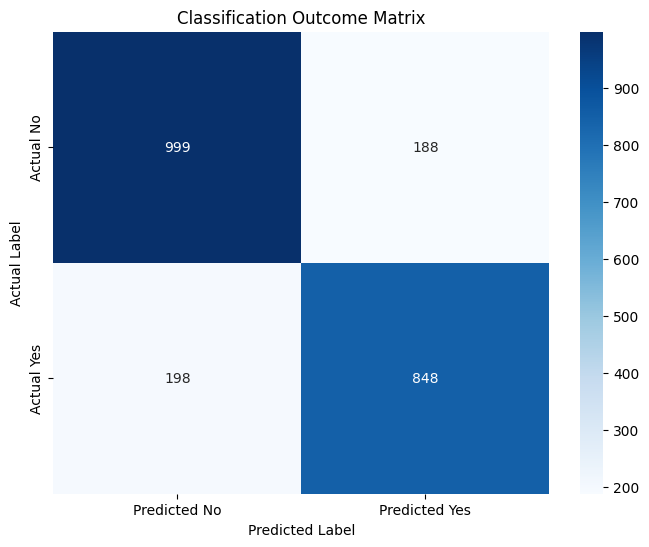

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Classification Outcome Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Custom Logistic Regression Implementation
This cell defines two functions: `sigmoid` for the activation function and `train_logistic_regression` for training a logistic regression model from scratch using gradient descent. It also includes a `predict` function for making predictions with the custom model.

In [30]:
def sigmoid(z):
    z = np.array(z)
    return 1 / (1 + np.exp(-z))

def train_logistic_regression(X, y, lr=0.1, epochs=2000):
    X = np.array(X, dtype=np.float64)
    y = np.array(y, dtype=np.float64)

    m, n = X.shape
    weights = np.zeros(n)

    for epoch in range(epochs):
        z = np.dot(X, weights)
        preds = sigmoid(z)

        gradient = (1 / m) * np.dot(X.T, (preds - y))
        weights -= lr * gradient

        if epoch % 500 == 0:
            loss = -(1 / m) * (
                np.dot(y, np.log(preds + 1e-9))
                + np.dot((1 - y), np.log(1 - preds + 1e-9))
            )
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return weights

def predict(X, weights, threshold=0.5):
    X = np.array(X, dtype=np.float64)
    return (sigmoid(np.dot(X, weights)) >= threshold).astype(int)

### Train and Predict with Custom Logistic Regression Model
This cell trains the custom logistic regression model using the scaled training data and then uses the trained weights to make predictions on the scaled test data.

In [31]:
# Train Custom Model
weights = train_logistic_regression(
    X_train_scaled, y_train, lr=0.1, epochs=2000
)

# Predict on test set
y_pred_custom = predict(X_test_scaled, weights, threshold=0.5)

Epoch 0, Loss: 0.6931
Epoch 500, Loss: 0.4104
Epoch 1000, Loss: 0.4099
Epoch 1500, Loss: 0.4099


### Calculate Accuracy of Custom Model
This cell calculates and prints the accuracy of the predictions made by the custom-implemented logistic regression model.

In [32]:
# Calculate Accuracy
custom_accuracy = np.mean(y_pred_custom == y_test)
print("\nFinal Accuracy:", custom_accuracy)


Final Accuracy: 0.8217644424540976


### Compare Model Performance
This cell constructs a pandas DataFrame to compare the performance metrics (Accuracy, Precision, Recall, F1 Score) of the scikit-learn Logistic Regression model against the custom-implemented Logistic Regression model.

In [33]:
# Build comparison table
results = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Scikit-Learn (Balanced)": [
        accuracy_score(y_test, y_pred_sklearn),
        precision_score(y_test, y_pred_sklearn),
        recall_score(y_test, y_pred_sklearn),
        f1_score(y_test, y_pred_sklearn),
    ],
    "Custom Sigmoid (From Scratch)": [
        accuracy_score(y_test, y_pred_custom),
        precision_score(y_test, y_pred_custom),
        recall_score(y_test, y_pred_custom),
        f1_score(y_test, y_pred_custom),
    ],
}

# Convert to DataFrame and display
comparison_df = pd.DataFrame(results)
display(comparison_df)

,Metric,Scikit-Learn (Balanced),Custom Sigmoid (From Scratch)
0,Accuracy,0.827138,0.821764
1,Precision,0.818533,0.824649
2,Recall,0.810707,0.786807
3,F1 Score,0.814601,0.805284


### Display Comparison Table
This cell displays the DataFrame that summarizes and compares the performance metrics of both the scikit-learn and custom-implemented logistic regression models.